In [1]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart.csv


In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.metrics import precision_score, recall_score, f1_score,roc_curve,roc_auc_score

In [4]:
df=pd.read_csv("heart.csv")
print(df.shape)
print(df.info())
print(df.head())

(918, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP 

HeartDisease
1    508
0    410
Name: count, dtype: int64
HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64


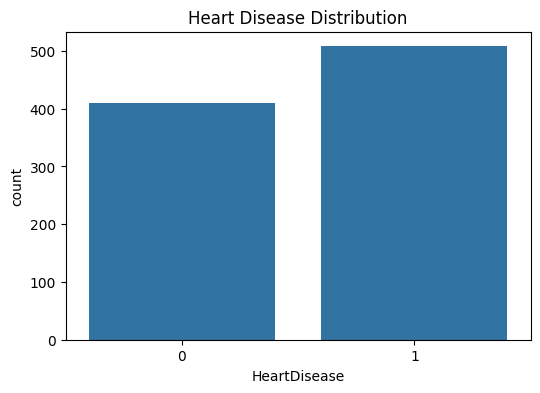

In [6]:
print(df["HeartDisease"].value_counts())
print(df["HeartDisease"].value_counts(normalize=True) * 100)  # percentage

plt.figure(figsize=(6,4))
sns.countplot(x="HeartDisease", data=df)
plt.title("Heart Disease Distribution")
plt.show()

In [7]:
categorical_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].unique())


Sex:
['M' 'F']

ChestPainType:
['ATA' 'NAP' 'ASY' 'TA']

RestingECG:
['Normal' 'ST' 'LVH']

ExerciseAngina:
['N' 'Y']

ST_Slope:
['Up' 'Flat' 'Down']


In [8]:
df["Sex"] = df["Sex"].map({"M": 1, "F": 0})
df["ExerciseAngina"] = df["ExerciseAngina"].map({"Y": 1, "N": 0})
nominal_cols = ["ChestPainType", "RestingECG", "ST_Slope"]
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
print(df.shape)
print(df.dtypes)

(918, 16)
Age                    int64
Sex                    int64
RestingBP              int64
Cholesterol            int64
FastingBS              int64
MaxHR                  int64
ExerciseAngina         int64
Oldpeak              float64
HeartDisease           int64
ChestPainType_ATA       bool
ChestPainType_NAP       bool
ChestPainType_TA        bool
RestingECG_Normal       bool
RestingECG_ST           bool
ST_Slope_Flat           bool
ST_Slope_Up             bool
dtype: object


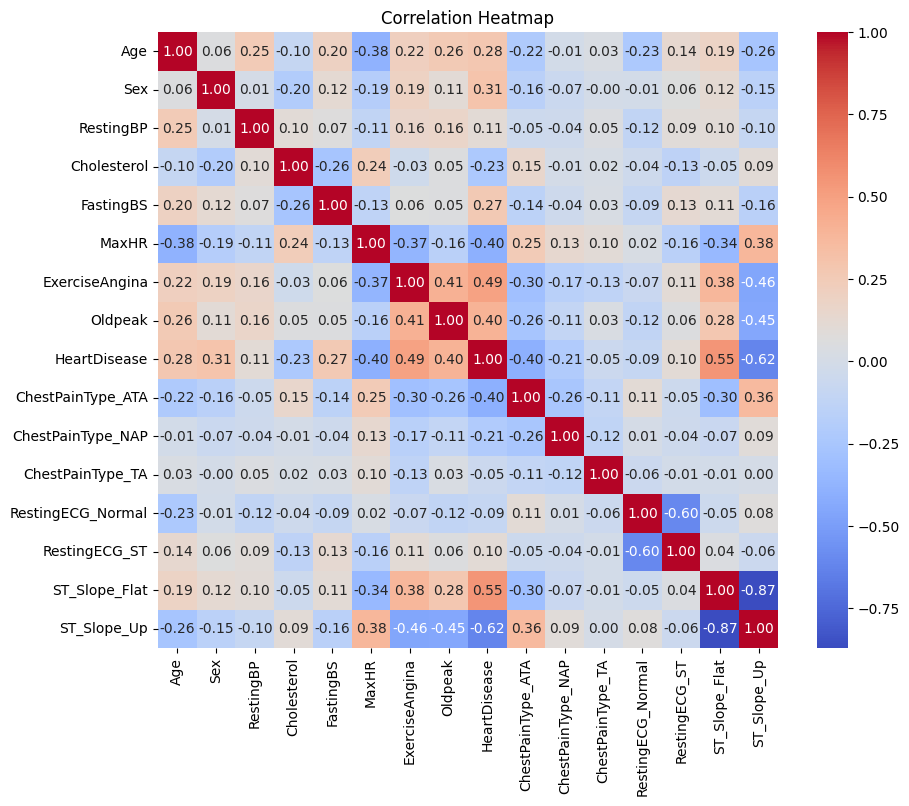

HeartDisease         1.000000
ST_Slope_Flat        0.554134
ExerciseAngina       0.494282
Oldpeak              0.403951
Sex                  0.305445
Age                  0.282039
FastingBS            0.267291
RestingBP            0.107589
RestingECG_ST        0.102527
ChestPainType_TA    -0.054790
RestingECG_Normal   -0.091580
ChestPainType_NAP   -0.212964
Cholesterol         -0.232741
MaxHR               -0.400421
ChestPainType_ATA   -0.401924
ST_Slope_Up         -0.622164
Name: HeartDisease, dtype: float64


In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()
print(df.corr()["HeartDisease"].sort_values(ascending=False))

In [11]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LogisticRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.8532608695652174


[[67 10]
 [17 90]]


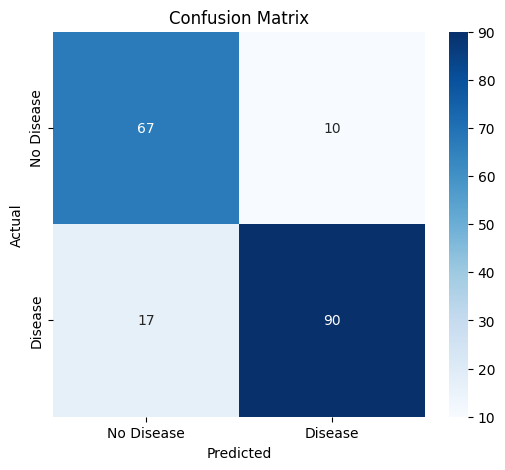

In [12]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [14]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(classification_report(y_test, y_pred))

Precision: 0.9000
Recall: 0.8411
F1-Score: 0.8696
              precision    recall  f1-score   support

           0       0.80      0.87      0.83        77
           1       0.90      0.84      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184



In [15]:
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred_new = (y_pred_proba >= 0.3).astype(int)

print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

           0       0.86      0.84      0.85        77
           1       0.89      0.90      0.89       107

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.88      0.87       184



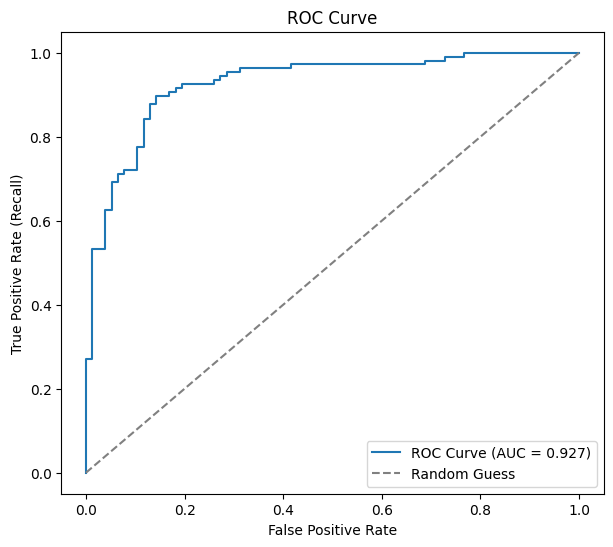

AUC Score: 0.9266901322976089


In [17]:
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", auc_score)